In [1]:
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from datetime import datetime, timedelta

# Locate premier_league/ regardless of where Jupyter was launched
_here = Path.cwd()
if not (_here / 'model_traces').exists():
    for _c in [_here / 'premier_league',
               _here / 'non_penalty_bayes' / 'premier_league',
               _here / 'team_strength' / 'non_penalty_bayes' / 'premier_league']:
        if _c.exists():
            os.chdir(_c)
            break

NOTEBOOK_DIR = Path.cwd().resolve()
NP_BAYES_DIR = str(NOTEBOOK_DIR.parent)
sys.path.insert(0, NP_BAYES_DIR)

REPO_ROOT = str(NOTEBOOK_DIR.parents[4])
sys.path.insert(0, os.path.join(REPO_ROOT, 'viz'))

from src.data_utils import load_and_process_data, load_football_data, create_weighted_scoreline_data, prepare_model_data
from src.model import build_and_sample_model
from src.simulation import (run_multiple_seasons, load_actual_results,
                             get_actual_standings, form_net_rating,
                             get_last_result, get_form_string, rank_arrow)
from pl_combined_table import render_combined_table
from pl_html_export import render_html_export

LEAGUE  = 'Premier_League'
SEASON  = '2025-2026'

DB_PATH = os.path.join(REPO_ROOT, 'infra', 'data', 'db', 'fotmob.db')

# Sampling
N_SAMPLES           = 20000
N_TUNE              = 10000
N_SAMPLES_EVOLUTION = 2000
N_TUNE_EVOLUTION    = 1000

# Blend weights
DECAY_RATE   = 0.0077
GOALS_WEIGHT = 0.25
XG_WEIGHT    = 0.50
PSXG_WEIGHT  = 0.15
EPV_WEIGHT   = 0.10

BASELINE_HOME_PENS = 0.157 * 0.78
BASELINE_AWAY_PENS = 0.101 * 0.78

# ── Form window config (update each week) ────────────────────────────────────
FORM_END      = '2026-04-06'
FORM_START    = '2025-11-24'
FORM_PREV_END = (datetime.strptime(FORM_END, '%Y-%m-%d') - timedelta(weeks=1)).strftime('%Y-%m-%d')

# ── Team logos (FPL CDN) ─────────────────────────────────────────────────────
team_logos = {
    'Arsenal':        'https://resources.premierleague.com/premierleague/badges/t3.png',
    'Aston Villa':    'https://resources.premierleague.com/premierleague/badges/t7.png',
    'Bournemouth':    'https://resources.premierleague.com/premierleague/badges/t91.png',
    'Brentford':      'https://resources.premierleague.com/premierleague/badges/t94.png',
    'Brighton':       'https://resources.premierleague.com/premierleague/badges/t36.png',
    'Burnley':        'https://resources.premierleague.com/premierleague/badges/t90.png',
    'Chelsea':        'https://resources.premierleague.com/premierleague/badges/t8.png',
    'Crystal Palace': 'https://resources.premierleague.com/premierleague/badges/t31.png',
    'Everton':        'https://resources.premierleague.com/premierleague/badges/t11.png',
    'Fulham':         'https://resources.premierleague.com/premierleague/badges/t54.png',
    'Leeds':          'https://resources.premierleague.com/premierleague/badges/t2.png',
    'Liverpool':      'https://r2.thesportsdb.com/images/media/team/badge/kfaher1737969724.png',
    'Man City':       'https://resources.premierleague.com/premierleague/badges/t43.png',
    'Man United':     'https://resources.premierleague.com/premierleague/badges/t1.png',
    'Newcastle':      'https://resources.premierleague.com/premierleague/badges/t4.png',
    'Nottm Forest':   'https://resources.premierleague.com/premierleague/badges/t17.png',
    'Tottenham':      'https://resources.premierleague.com/premierleague/badges/t6.png',
    'Sunderland':     'https://resources.premierleague.com/premierleague/badges/t56.png',
    'West Ham':       'https://resources.premierleague.com/premierleague/badges/t21.png',
    'Wolves':         'https://resources.premierleague.com/premierleague/badges/t39.png',
}

print(f'CWD:          {NOTEBOOK_DIR}')
print(f'DB:           {DB_PATH}')
print(f'FORM_END:     {FORM_END}')
print(f'FORM_PREV_END:{FORM_PREV_END}')

CWD:          /Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/premier_league
DB:           /Users/admin/dev/algobetting/infra/data/db/fotmob.db
FORM_END:     2026-04-06
FORM_PREV_END:2026-03-30


## Current ratings — full season

In [2]:
df, team_mapping, n_teams = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON,
    decay_rate=DECAY_RATE, goals_weight=GOALS_WEIGHT,
    xg_weight=XG_WEIGHT, psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
)
team_names = list(team_mapping.keys())
print(f'{n_teams} teams, {df["match_id"].nunique()} matches')

20 teams, 309 matches


In [3]:
from manual_priors import MANUAL_ATT_PRIORS, MANUAL_DEF_PRIORS

_, trace = build_and_sample_model(
    df, n_teams, trace=N_SAMPLES, tune=N_TUNE,
    team_mapping=team_mapping,
    manual_att_priors=MANUAL_ATT_PRIORS,
    manual_def_priors=MANUAL_DEF_PRIORS,
)
print('Done.')

Done.


In [4]:
posterior = trace.posterior
att  = posterior['att_str'].values.reshape(-1, n_teams)
defn = posterior['def_str'].values.reshape(-1, n_teams)
hadv = posterior['home_adv'].values.reshape(-1)
base = posterior['baseline'].values.reshape(-1)

ratings = pd.DataFrame({
    'team':     team_names,
    'att_mean': att.mean(axis=0).round(3),
    'att_sd':   att.std(axis=0).round(3),
    'att_lo':   np.percentile(att, 5,  axis=0).round(3),
    'att_hi':   np.percentile(att, 95, axis=0).round(3),
    'def_mean': defn.mean(axis=0).round(3),
    'def_sd':   defn.std(axis=0).round(3),
    'def_lo':   np.percentile(defn, 5,  axis=0).round(3),
    'def_hi':   np.percentile(defn, 95, axis=0).round(3),
})
ratings['net'] = (ratings['att_mean'] - ratings['def_mean']).round(3)
ratings = ratings.sort_values('net', ascending=False).reset_index(drop=True)
ratings

,team,att_mean,att_sd,att_lo,att_hi,def_mean,def_sd,def_lo,def_hi,net
0,Arsenal,0.257,0.170,-0.030,0.529,-0.434,0.223,-0.801,-0.081,0.691
1,Man City,0.278,0.173,-0.011,0.555,-0.164,0.209,-0.515,0.171,0.442
2,Liverpool,0.262,0.175,-0.029,0.549,-0.086,0.202,-0.424,0.236,0.348
3,Chelsea,0.221,0.174,-0.067,0.500,-0.020,0.199,-0.346,0.301,0.241
4,Man United,0.139,0.186,-0.173,0.429,-0.085,0.195,-0.416,0.231,0.224
5,Brighton,0.047,0.195,-0.281,0.358,-0.097,0.201,-0.436,0.223,0.144
6,Brentford,0.080,0.185,-0.224,0.376,-0.055,0.191,-0.378,0.251,0.135
7,Newcastle,0.092,0.189,-0.220,0.392,0.025,0.196,-0.297,0.340,0.067
8,Aston Villa,0.059,0.192,-0.269,0.376,0.027,0.195,-0.304,0.338,0.032
9,Bournemouth,0.089,0.185,-0.221,0.381,0.091,0.183,-0.224,0.383,-0.002


/var/folders/7c/dkh0wxt56g39m3h9nmfq79mc0000gn/T/ipykernel_13755/915107938.py:12: UserWarning: Glyph 8593 (\N{UPWARDS ARROW}) missing from font(s) Roboto.
  plt.tight_layout()
/var/folders/7c/dkh0wxt56g39m3h9nmfq79mc0000gn/T/ipykernel_13755/915107938.py:12: UserWarning: Glyph 8595 (\N{DOWNWARDS ARROW}) missing from font(s) Roboto.
  plt.tight_layout()
/Users/admin/dev/algobetting/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8595 (\N{DOWNWARDS ARROW}) missing from font(s) Roboto.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/admin/dev/algobetting/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8593 (\N{UPWARDS ARROW}) missing from font(s) Roboto.
  fig.canvas.print_figure(bytes_io, **kw)


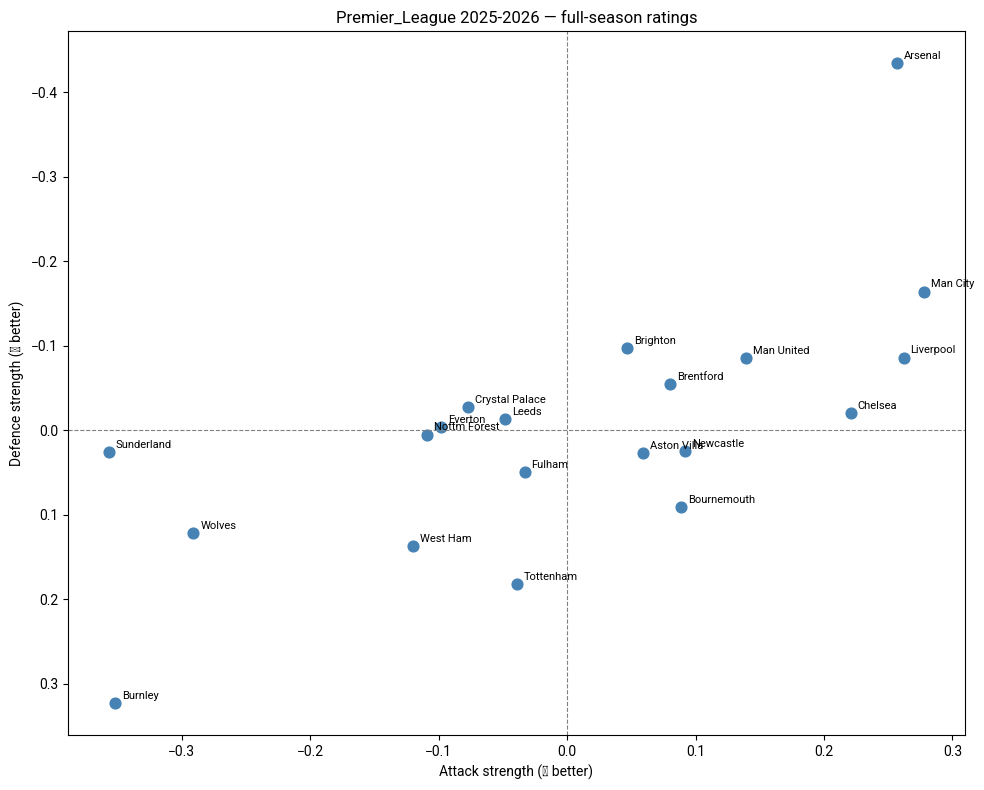

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(ratings['att_mean'], ratings['def_mean'], s=60, color='steelblue')
for _, row in ratings.iterrows():
    ax.annotate(row['team'], (row['att_mean'], row['def_mean']),
                textcoords='offset points', xytext=(5, 3), fontsize=8)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Attack strength (↑ better)')
ax.set_ylabel('Defence strength (↓ better)')
ax.set_title(f'{LEAGUE} {SEASON} — full-season ratings')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Season Projections

In [6]:
# ── ratings_df: Bayesian avg-vs-all-opponents (Jensen's corrected) ────────────
baseline_samples  = trace.posterior['baseline'].values.flatten()
home_adv_samples  = trace.posterior['home_adv'].values.flatten()
att_samples_all   = trace.posterior['att_str'].values.reshape(-1, n_teams)
def_samples_all   = trace.posterior['def_str'].values.reshape(-1, n_teams)
all_teams_list    = list(team_mapping.keys())

team_stats = {t: {'goals_for': 0, 'goals_against': 0, 'matches': 0} for t in all_teams_list}

for home_team in all_teams_list:
    hi = team_mapping[home_team]
    for away_team in all_teams_list:
        if home_team == away_team:
            continue
        ai = team_mapping[away_team]
        home_lam = np.exp(baseline_samples + home_adv_samples
                          + att_samples_all[:, hi] + def_samples_all[:, ai])
        away_lam = np.exp(baseline_samples + att_samples_all[:, ai] + def_samples_all[:, hi])

        hg = home_lam.mean() + BASELINE_HOME_PENS
        ag = away_lam.mean() + BASELINE_AWAY_PENS

        team_stats[home_team]['goals_for']     += hg
        team_stats[home_team]['goals_against'] += ag
        team_stats[home_team]['matches']       += 1
        team_stats[away_team]['goals_for']     += ag
        team_stats[away_team]['goals_against'] += hg
        team_stats[away_team]['matches']       += 1

ratings_df = pd.DataFrame([{
    'team':          t,
    'goals_for':     team_stats[t]['goals_for']     / team_stats[t]['matches'],
    'goals_against': team_stats[t]['goals_against'] / team_stats[t]['matches'],
    'goal_diff':     (team_stats[t]['goals_for'] - team_stats[t]['goals_against']) / team_stats[t]['matches'],
} for t in all_teams_list]).sort_values('goal_diff', ascending=False).reset_index(drop=True)

print(ratings_df.to_string(index=False))

          team  goals_for  goals_against  goal_diff
       Arsenal   1.753337       0.916982   0.836356
      Man City   1.772179       1.165368   0.606810
     Liverpool   1.740215       1.250061   0.490153
       Chelsea   1.670001       1.331190   0.338811
    Man United   1.553133       1.259128   0.294005
      Brighton   1.428667       1.252120   0.176547
     Brentford   1.468742       1.297875   0.170867
     Newcastle   1.480335       1.396917   0.083418
   Aston Villa   1.436084       1.401609   0.034475
   Bournemouth   1.470767       1.482432  -0.011664
         Leeds   1.310002       1.359326  -0.049325
Crystal Palace   1.272897       1.343979  -0.071083
        Fulham   1.316879       1.436608  -0.119729
       Everton   1.245684       1.370562  -0.124878
  Nottm Forest   1.235680       1.383911  -0.148231
     Tottenham   1.300890       1.624135  -0.323245
      West Ham   1.215129       1.561718  -0.346589
    Sunderland   0.993550       1.425904  -0.432355
        Wolv

In [7]:
# ── Load actual results + run 10k simulations ─────────────────────────────────
df_actual = load_actual_results(DB_PATH, LEAGUE, SEASON)
print(f'Actual matches: {len(df_actual)}')

N_SIMS = 10_000
avg_table, position_freq = run_multiple_seasons(
    N_SIMS, trace, team_mapping, df_actual
)
avg_table

Actual matches: 309
Pre-computing xG for 380 fixtures...
  Played: 309   To simulate: 71
Running 10,000 simulations...
  2,000 / 10,000
  4,000 / 10,000
  6,000 / 10,000
  8,000 / 10,000


,team,avg_points,pts_low,pts_high,avg_wins,avg_draws,avg_losses,avg_goals_for,avg_goals_against,avg_xg_for,avg_xg_against,avg_position,title_pct,top5_pct,top8_pct,relegation_pct,avg_goal_difference,avg_xg_difference
1,Arsenal,83.9169,79.821821,88.011979,25.1317,8.5218,4.3465,74.0001,28.3958,66.626823,34.845304,1.0417,95.8,100.0,100.0,0.0,45.6043,31.781520
2,Man City,74.8404,70.141261,79.539539,21.9968,8.8500,7.1532,73.9338,37.6287,67.342791,44.283996,2.0087,4.2,100.0,100.0,0.0,36.3051,23.058794
3,Man United,65.8112,61.396748,70.225652,18.0320,11.7152,8.2528,66.5486,51.8522,59.019055,47.846866,3.6449,0.0,94.1,99.9,0.0,14.6964,11.172189
4,Aston Villa,64.2309,59.872244,68.589556,18.8499,7.6812,11.4689,52.4497,46.5975,54.571208,53.261150,4.2222,0.0,87.2,99.6,0.0,5.8522,1.310059
5,Liverpool,60.5849,56.162321,65.007479,17.3143,8.6420,12.0437,61.9648,51.0210,66.128158,47.502336,5.4737,0.0,56.5,95.1,0.0,10.9438,18.625822
6,Chelsea,58.8701,54.392656,63.347544,16.0814,10.6259,11.2927,64.4686,47.6295,63.460036,50.585233,6.1470,0.0,39.0,89.5,0.0,16.8391,12.874803
7,Brentford,56.1556,51.813137,60.498063,15.8242,8.6830,13.4928,56.1164,51.4417,55.812207,49.319244,7.8832,0.0,11.6,65.2,0.0,4.6747,6.492963
8,Everton,54.8513,50.552179,59.150421,15.3417,8.8262,13.8321,45.5959,44.7001,47.335986,52.081360,8.8748,0.0,5.3,46.0,0.0,0.8958,-4.745374
9,Brighton,53.9360,49.539185,58.332815,14.0653,11.7401,12.1946,51.5040,45.5579,54.289337,47.580554,9.1343,0.0,3.8,42.4,0.0,5.9461,6.708783
10,Fulham,52.2143,48.071651,56.356949,15.1746,6.6905,16.1349,51.7632,54.9733,50.041398,54.591085,10.6254,0.0,0.8,18.7,0.0,-3.2101,-4.549688


/Users/admin/dev/algobetting/viz/pl_combined_table.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


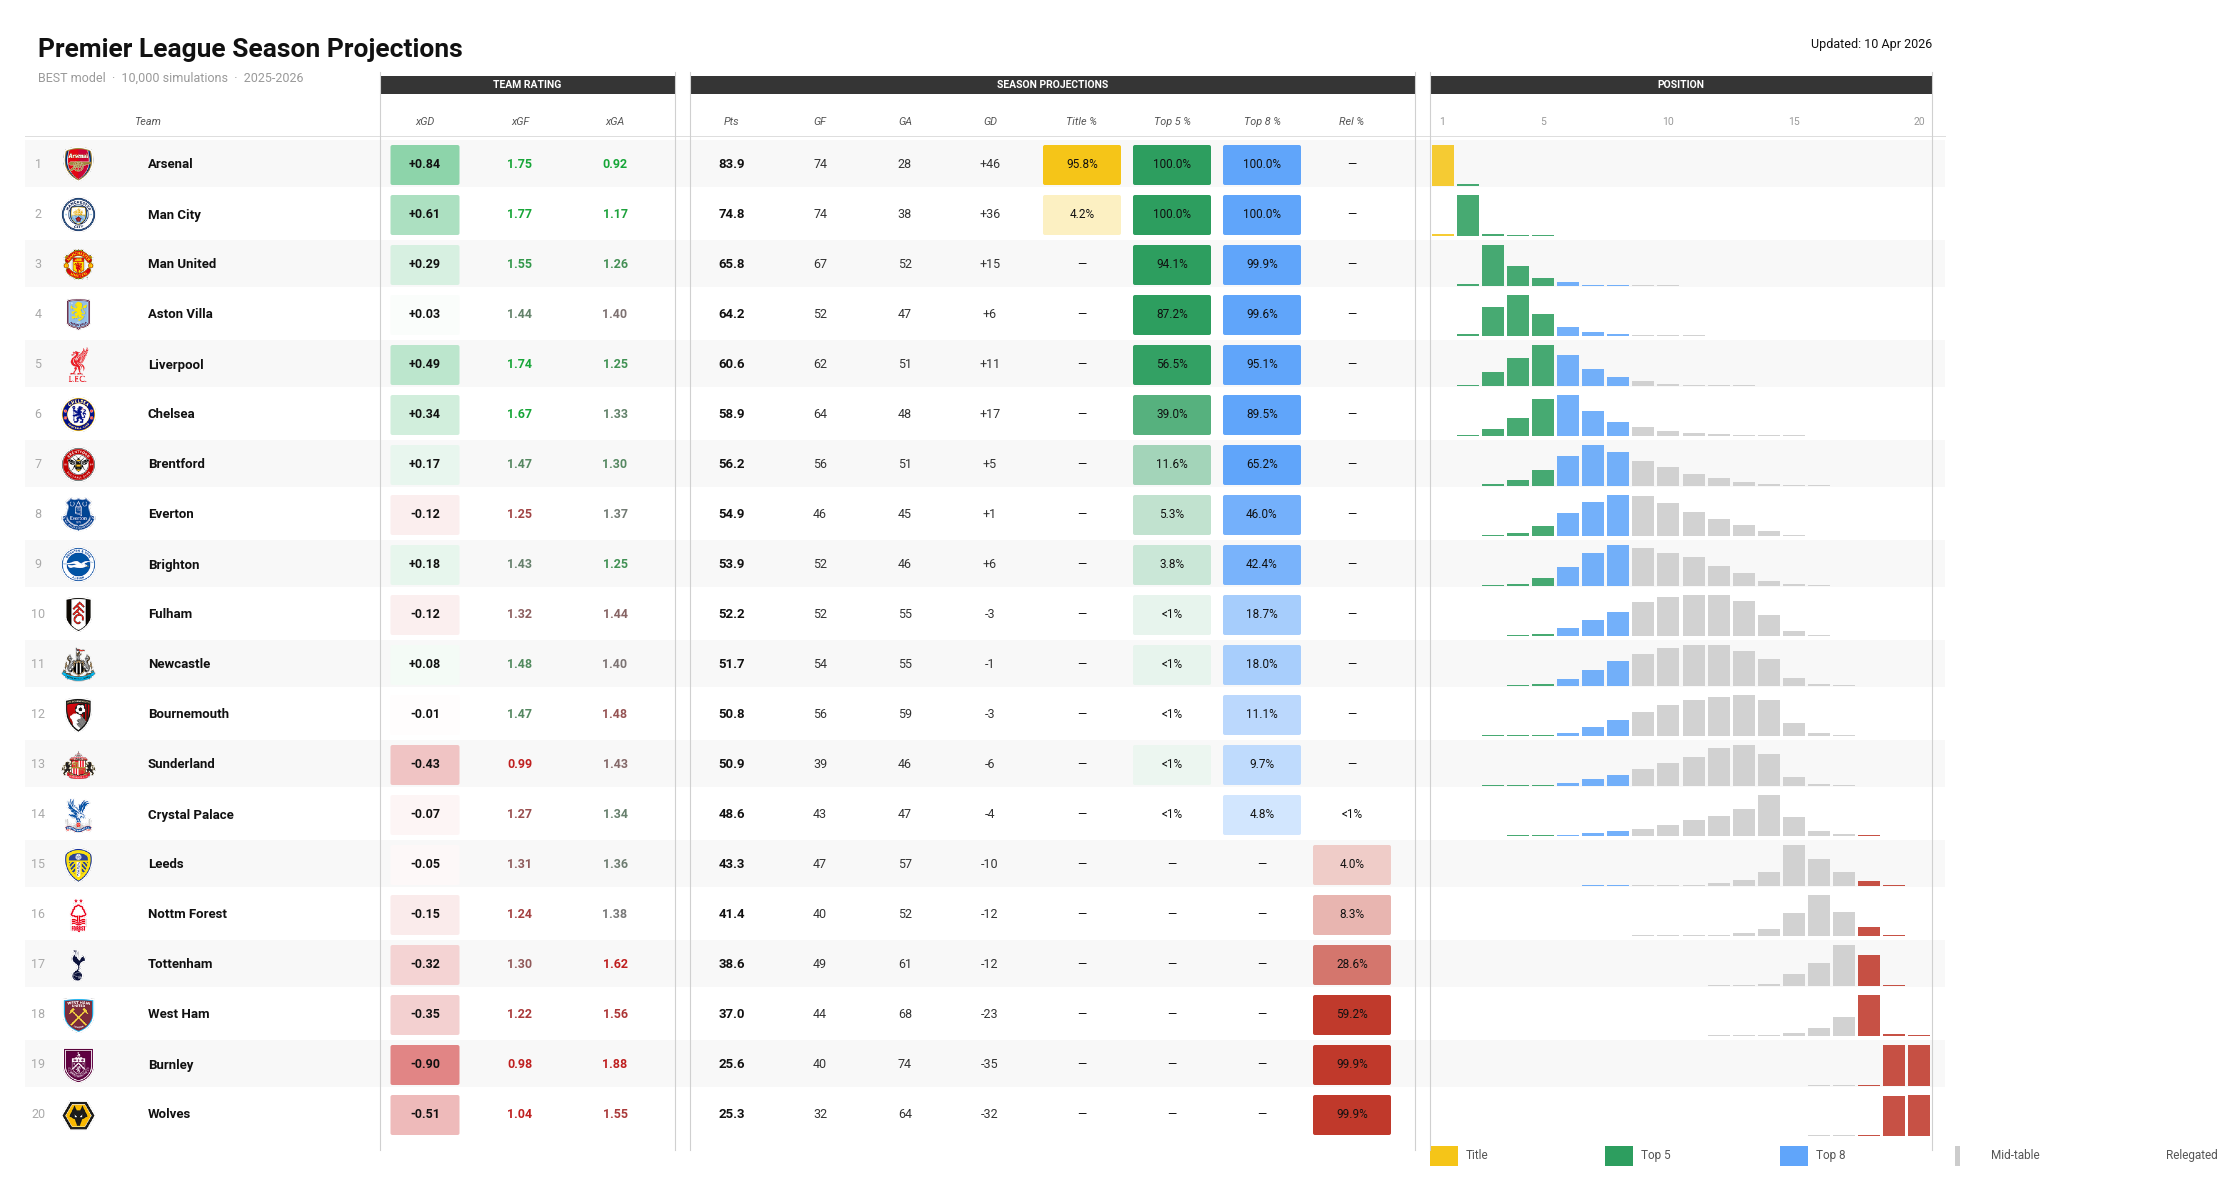

In [8]:
# ── 538-style combined table ──────────────────────────────────────────────────
fig = render_combined_table(
    avg_table     = avg_table,
    position_freq = position_freq,
    ratings_df    = ratings_df,
    n_sims        = N_SIMS,
    season        = SEASON,
    team_logos    = team_logos,
)
plt.show()

## Power rankings — short window + season simulation

In [ ]:
# Adjust WINDOW_START each week
WINDOW_START = '2025-12-01'

pr_df, pr_map, pr_n = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON, start=WINDOW_START,
    decay_rate=0.025, goals_weight=GOALS_WEIGHT,
    xg_weight=XG_WEIGHT, psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
)
print(f'Window: {WINDOW_START} → latest  |  {pr_n} teams, {pr_df["match_id"].nunique()} matches')

_, pr_trace = build_and_sample_model(pr_df, pr_n, trace=N_SAMPLES, tune=N_TUNE, team_mapping=pr_map)
print('Done.')

In [ ]:
pr_teams    = list(pr_map.keys())
pr_n_teams  = len(pr_teams)
pr_team_idx = {name: i for i, name in enumerate(pr_teams)}
pr_post     = pr_trace.posterior
pr_att  = pr_post['att_str'].values.reshape(-1, pr_n_teams)
pr_defn = pr_post['def_str'].values.reshape(-1, pr_n_teams)
pr_hadv = pr_post['home_adv'].values.reshape(-1)
pr_base = pr_post['baseline'].values.reshape(-1)

match_df, _, _, _ = load_football_data(DB_PATH, LEAGUE, SEASON)
played    = match_df[match_df['home_goals'].notna()].copy()
remaining = match_df[match_df['home_goals'].isna()].copy()
print(f'Played: {len(played)}   Remaining: {len(remaining)}')

def fixture_xg(home, away, n_samples=2_000):
    if home not in pr_team_idx or away not in pr_team_idx:
        return None, None
    hi, ai = pr_team_idx[home], pr_team_idx[away]
    s = np.random.choice(len(pr_base), size=n_samples, replace=True)
    return (
        np.exp(pr_base[s] + pr_att[s, hi] + pr_defn[s, ai] + pr_hadv[s]).mean(),
        np.exp(pr_base[s] + pr_att[s, ai] + pr_defn[s, hi]).mean(),
    )

actual_pts = {t: 0 for t in pr_teams}
for _, row in played.iterrows():
    h, a = row['home_team'], row['away_team']
    if h not in actual_pts or a not in actual_pts: continue
    if   row['home_goals'] > row['away_goals']: actual_pts[h] += 3
    elif row['home_goals'] < row['away_goals']: actual_pts[a] += 3
    else: actual_pts[h] += 1; actual_pts[a] += 1

fixture_cache = {}
for _, row in remaining.iterrows():
    key = (row['home_team'], row['away_team'])
    if key not in fixture_cache:
        fixture_cache[key] = fixture_xg(*key)

N_SIMS    = 5_000
all_ranks = []
for _ in range(N_SIMS):
    pts = actual_pts.copy()
    for (home, away), (h_xg, a_xg) in fixture_cache.items():
        if h_xg is None: continue
        hg, ag = np.random.poisson(h_xg), np.random.poisson(a_xg)
        if   hg > ag: pts[home] += 3
        elif ag > hg: pts[away] += 3
        else: pts[home] += 1; pts[away] += 1
    all_ranks.append(pd.Series(pts).rank(ascending=False, method='min').astype(int))

sim_df = pd.DataFrame(all_ranks)
power  = pd.DataFrame({
    'team':         pr_teams,
    'current_pts':  [actual_pts[t] for t in pr_teams],
    'title_%':      [(sim_df[t] == 1).mean() * 100 for t in pr_teams],
    'top4_%':       [(sim_df[t] <= 4).mean() * 100 for t in pr_teams],
    'top5_%':       [(sim_df[t] <= 5).mean() * 100 for t in pr_teams],
    'relegation_%': [(sim_df[t] >= 18).mean() * 100 for t in pr_teams],
})
power.sort_values('current_pts', ascending=False).reset_index(drop=True).round(1)

## HTML Power Rankings Export

Generates `substack_power_rankings.html`. Open in browser → Select All (Cmd+A) → Copy → Paste into Substack.

In [ ]:
# ── Form ratings: current window vs previous week ─────────────────────────────
df_form_current, _, _ = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON,
    start=FORM_START, end=FORM_END,
    decay_rate=0.025,
    goals_weight=GOALS_WEIGHT, xg_weight=XG_WEIGHT,
    psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
)
form_current = form_net_rating(df_form_current)
form_current['form_rank'] = range(1, len(form_current) + 1)

df_form_prev, _, _ = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON,
    start=FORM_START, end=FORM_PREV_END,
    decay_rate=0.025,
    goals_weight=GOALS_WEIGHT, xg_weight=XG_WEIGHT,
    psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
)
form_prev = form_net_rating(df_form_prev)
form_prev['prev_form_rank'] = range(1, len(form_prev) + 1)

form_merged = form_current.merge(
    form_prev[['prev_form_rank']], left_index=True, right_index=True, how='left'
)
print(form_merged[['net_rating', 'form_rank', 'prev_form_rank']].head(10))

# ── Actual standings ──────────────────────────────────────────────────────────
played = df_actual[df_actual['home_goals'].notna()].copy()
_teams = list(team_mapping.keys())
pts_d = {t: 0 for t in _teams}
gf_d  = {t: 0 for t in _teams}
ga_d  = {t: 0 for t in _teams}
for _, r in played.iterrows():
    h, a = r['home_team'], r['away_team']
    if h not in pts_d or a not in pts_d:
        continue
    hg, ag = int(r['home_goals']), int(r['away_goals'])
    gf_d[h] += hg; ga_d[h] += ag
    gf_d[a] += ag; ga_d[a] += hg
    if   hg > ag: pts_d[h] += 3
    elif ag > hg: pts_d[a] += 3
    else:         pts_d[h] += 1; pts_d[a] += 1

standings = pd.DataFrame({
    'team': _teams,
    'pts':  [pts_d[t] for t in _teams],
    'gf':   [gf_d[t]  for t in _teams],
    'ga':   [ga_d[t]  for t in _teams],
    'gd':   [gf_d[t] - ga_d[t] for t in _teams],
}).sort_values(['pts', 'gd', 'gf'], ascending=False).reset_index(drop=True)
standings['table_pos'] = range(1, len(standings) + 1)

# ── Ratings ranks ─────────────────────────────────────────────────────────────
ratings_ranked = ratings_df.copy()
ratings_ranked['att_rank'] = ratings_ranked['goals_for'].rank(ascending=False).astype(int)
ratings_ranked['def_rank'] = ratings_ranked['goals_against'].rank(ascending=True).astype(int)
print(standings[['team', 'pts', 'gd', 'table_pos']].to_string(index=False))

In [ ]:
# ── Generate Substack HTML ────────────────────────────────────────────────────
output_html = os.path.join(str(NOTEBOOK_DIR), 'substack_power_rankings.html')
render_html_export(
    form_merged    = form_merged,
    standings      = standings,
    ratings_ranked = ratings_ranked,
    team_logos     = team_logos,
    df_actual      = df_actual,
    form_end       = FORM_END,
    output_path    = output_html,
    get_last_result = get_last_result,
    get_form_string = get_form_string,
    rank_arrow      = rank_arrow,
)

## Ratings evolution — GW5 onwards

Fits the model after each gameweek and tracks how team strengths change across the season.

**Runtime note:** at 20k/10k draws this loop takes a while (~15 min per GW).
Lower `N_SAMPLES_EVOLUTION` in the setup cell if you want it faster.

In [ ]:
# Identify gameweek cutoff dates from the actual fixture schedule
# A new GW starts after a gap of >3 days between match batches
match_df_evo, _, _, _ = load_football_data(DB_PATH, LEAGUE, SEASON)
played_evo = match_df_evo[match_df_evo['home_goals'].notna()].copy()
played_evo['match_date'] = pd.to_datetime(played_evo['match_date'])

dates_sorted = sorted(played_evo['match_date'].dt.date.unique())

def get_gw_cutoffs(dates, gap_days=3):
    """Return the last date of each gameweek batch."""
    gw_ends, batch = [], [dates[0]]
    for i in range(1, len(dates)):
        if (dates[i] - dates[i-1]).days > gap_days:
            gw_ends.append(batch[-1])
            batch = []
        batch.append(dates[i])
    gw_ends.append(batch[-1])
    return gw_ends

gw_cutoffs = get_gw_cutoffs(dates_sorted)
print(f'{len(gw_cutoffs)} gameweeks detected')
print(f'GW1 end: {gw_cutoffs[0]}   GW5 end: {gw_cutoffs[4]}   Last GW: {gw_cutoffs[-1]}')

In [ ]:
# Consistent team index across all GW iterations
all_teams = sorted(set(played_evo['home_team'].unique()) | set(played_evo['away_team'].unique()))
full_map  = {t: i for i, t in enumerate(all_teams)}
n_all     = len(all_teams)

def fit_gw(cutoff_date):
    """Fit model on all data up to cutoff_date, return posterior mean att/def per team."""
    gw_df, _, _ = load_and_process_data(
        db_path=DB_PATH, league=LEAGUE, season=SEASON,
        end=cutoff_date,
        decay_rate=DECAY_RATE, goals_weight=GOALS_WEIGHT,
        xg_weight=XG_WEIGHT, psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
    )
    # Override indices to use the full consistent team list
    gw_df = gw_df.copy()
    gw_df['home_idx'] = gw_df['home_team'].map(full_map).astype(int)
    gw_df['away_idx'] = gw_df['away_team'].map(full_map).astype(int)

    _, tr = build_and_sample_model(
        gw_df, n_all, trace=N_SAMPLES_EVOLUTION, tune=N_TUNE_EVOLUTION
    )
    post = tr.posterior
    return (
        post['att_str'].values.reshape(-1, n_all).mean(axis=0),
        post['def_str'].values.reshape(-1, n_all).mean(axis=0),
    )

# Run from GW5 onwards (index 4)
evo_records = []
for gw_num, cutoff in enumerate(gw_cutoffs[4:], start=5):
    print(f'GW{gw_num} ({cutoff})...', end=' ', flush=True)
    att_means, def_means = fit_gw(cutoff)
    for i, team in enumerate(all_teams):
        evo_records.append({
            'gw':      gw_num,
            'date':    cutoff,
            'team':    team,
            'att':     att_means[i],
            'def':     def_means[i],
            'net':     att_means[i] - def_means[i],
        })
    print('done')

evo_df = pd.DataFrame(evo_records)
print(f'Evolution data: {len(evo_df)} rows')

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=True)
colors = cm.tab20(np.linspace(0, 1, len(all_teams)))

for ax, metric, title in zip(
    axes,
    ['net', 'att', 'def'],
    ['Net strength (att − def)', 'Attack strength', 'Defence strength'],
):
    for i, team in enumerate(all_teams):
        t_df = evo_df[evo_df['team'] == team].sort_values('gw')
        ax.plot(t_df['gw'], t_df[metric], color=colors[i], linewidth=1.5, label=team)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.2)
    if metric == 'def':
        ax.invert_yaxis()  # lower def = better

axes[0].set_title(f'{LEAGUE} {SEASON} — ratings evolution from GW5')
axes[-1].set_xlabel('Gameweek')

# Legend outside on the right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5), fontsize=8)
plt.tight_layout()
plt.show()